# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-3B** với LoRA/QLoRA trên một custom Vietnamese dataset, sau đó so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`).

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-3B-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | "no" |
| Max seq length cap | 1024 |
| Dataset samples | 200 |
| Estimated time | ~60 phút trên T4 |

> ⚠️ **T4-specific tweaks**: dùng model 3B (thay vì 7B), tắt eval-during-training, batch size = 1, manual eval fallback. Nếu bạn có GPU lớn hơn, dùng phiên bản BigGPU.

## Lab Roadmap (≈ 2 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + qualitative) | so sánh metrics |
| 6 | Save + viết report | deliverable |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8, r=16, r=64`)
2. **Evaluation report** chứa training time, peak VRAM, eval perplexity, 5 qualitative before/after examples, training cost, kết luận về rank trade-off


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 04:44:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU thay vì T4 này — sẽ nhanh hơn nhiều!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) có thể chạy được nhưng underutilized.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128


In [3]:
# Install Unsloth, TRL, datasets, evaluation libs
# trl >= 0.12 — accepts processing_class (matches transformers >= 4.46)
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
# Optional: mount Google Drive to save checkpoints persistently
MOUNT_DRIVE = False  # ← đổi thành True nếu muốn save vào Drive

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4'
else:
    OUTPUT_DIR = '/content/lab21_lora_t4'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Output dir: /content/lab21_lora_t4


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [5]:
# ─── Option A: load Vietnamese Alpaca dataset từ HuggingFace ───
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(200))
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

✓ Loaded 200 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [6]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")

In [7]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

Token length distribution:
  min=25, max=738
  p50=227, p95=562, p99=704

✓ Chọn max_seq_length = 1024 (cap = 1024)


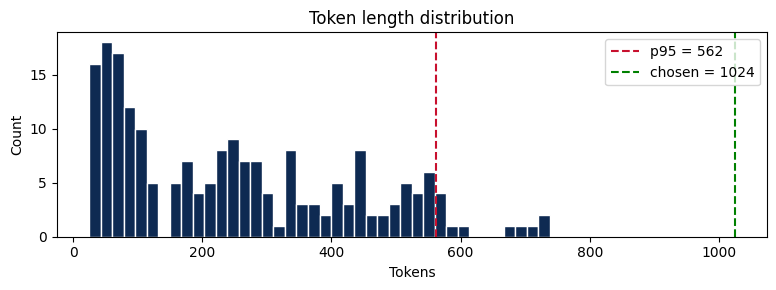

In [8]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-3B-bnb-4bit"
MAX_SEQ_CAP = 1024  # hard cap cho profile T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# 90/10 train/eval split
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 180  |  Eval: 20


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4). Unsloth tự động bật custom CUDA kernels.

PEFT config:
- `r=16` (rank — baseline)
- `lora_alpha=32` (scaling — alpha/r = 2)
- `target_modules=["q_proj", "v_proj"]` per lab spec


In [10]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],  # lab spec
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 3,686,400 (0.217% of 1,702,359,040)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=True
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: "no"  # T4 không đủ VRAM cho mid-train eval


In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "no"  # T4 không đủ VRAM cho mid-train eval
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove buggy notebook callback that breaks evaluate-after-train
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluate first
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual eval loop — bulletproof
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [12]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


...

Step,Training Loss
5,1.614305
10,1.573560
15,1.606689
20,1.555441
25,1.479080
30,1.416185
35,1.496181
40,1.480136
45,1.380218
50,1.388354


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-69/tokenizer_config.json.



✓ r=16 done in 4.2 min, peak VRAM = 6.6 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`Atten

✓ r=16 eval loss = 1.5161, perplexity = 4.55


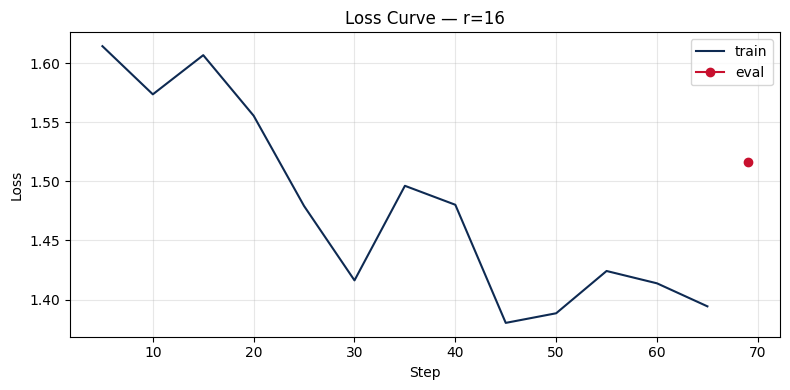


📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.


In [13]:
# Plot training loss để detect overfitting
import pandas as pd

def plot_losses(log_history, title="Training Loss"):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16")
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [14]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [15]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 3,087,781,888 (0.06% trained)


Step,Training Loss
5,1.616500
10,1.591786
15,1.633090
20,1.581143
25,1.512532
30,1.451584
35,1.532159
40,1.516283
45,1.417545
50,1.441451


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/tokenizer_config.json.


✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [16]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,745,600 of 3,100,684,288 (0.48% trained)


Step,Training Loss
5,1.601615
10,1.524071
15,1.547107
20,1.504727
25,1.425420
30,1.345464
35,1.402454
40,1.381225
45,1.297632
50,1.270547


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/tokenizer_config.json.


✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [17]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           1843200        4.049285      7.216138   1.557694         4.747861
   16     32           3686400        4.238800      6.617750   1.516083         4.554353
   64    128          14745600        4.042253      7.998512   1.476811         4.378959


## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 5 prompts (chạy full 20 nếu thời gian cho phép).

In [18]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 10 test prompts


In [19]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1: Giải thích khái niệm machine learning cho người mới bắt đầu....


...

  BASE: 1. Thân thiện với người dùng: Mục đích của thiết kế UI/UX là cung cấp trải nghiệm người dùng thân thiện, dễ sử dụng và thân thiện. Điều này có thể được thể hiện thông qua việc sắp xếp bố cục, màu sắc,...
  FT  : 1. Chuyển đổi: UI/UX thiết kế phải hướng tới việc giúp người dùng thực hiện hành động. 2. Thích ứng: UI/UX thiết kế phải thích ứng với nhiều loại thiết bị và kích thước màn hình. 3. Đơn giản: UI/UX th...

━━━ Prompt 4: Tóm tắt sự khác biệt giữa LoRA và QLoRA....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: LoRA (Low-Rank Adaptation) và QLoRA (Quantized LoRA) là hai phương pháp cải thiện hiệu năng của mô hình NLU (NLP) bằng cách sử dụng các phép biến đổi thấp độ phức tạp. LoRA là phương pháp cải thiện hi...
  FT  : LoRA (Layer-wise Adaptive Regularization Optimization) và QLoRA (Quantized LoRA) là hai phương pháp regularization được phát triển để cải thiện hiệu quả và độ ổn định của các mạng neural network trong...

━━━ Prompt 5: Phân biệt prompt engineering, RAG, và fine-tuning....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Prompt engineering, RAG (retrieval augmented generation), và fine-tuning là ba cách khác nhau để cải thiện hiệu suất của mô hình máy học. Prompt engineering là một kỹ thuật để cải thiện hiệu suất của ...
  FT  : Prompt engineering, RAG và fine-tuning là ba kỹ thuật khác nhau được sử dụng trong lĩnh vực AI và tự động hóa. Prompt engineering là một kỹ thuật tập trung vào việc xây dựng câu lệnh (prompt) để giúp ...


In [20]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Giải thích khái niệm machine learning cho ngườ...   
1     Viết đoạn code Python tính số Fibonacci thứ n.   
2               Liệt kê 5 nguyên tắc thiết kế UI/UX.   
3           Tóm tắt sự khác biệt giữa LoRA và QLoRA.   
4  Phân biệt prompt engineering, RAG, và fine-tun...   

                                                base  \
0  Machine learning là một phân khúc của trí tuệ ...   
1  Để tính số Fibonacci thứ n, bạn có thể sử dụng...   
2  1. Thân thiện với người dùng: Mục đích của thi...   
3  LoRA (Low-Rank Adaptation) và QLoRA (Quantized...   
4  Prompt engineering, RAG (retrieval augmented g...   

                                           finetuned  
0  Machine learning là một bộ môn công nghệ máy t...  
1  Để tính số Fibonacci thứ n, bạn có thể viết mộ...  
2  1. Chuyển đổi: UI/UX thiết kế phải hướng tới v...  
3  LoRA (Layer-wise Adaptive Regularization Optim...  
4  Prompt engineering, RAG và fine-tuning là ba k..

## 6. Save Adapters + Generate Report

In [21]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)

GPU_COST_USD_PER_HOUR = 0.35  # T4 default
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")


✓ Tổng training time: 12.3 phút
✓ Estimated cost: $0.07 (@ $0.35/hr)


In [22]:
# # Optional: push adapter to HuggingFace Hub
# PUSH_TO_HUB = False
# HUB_REPO_ID = "your-username/qwen2.5-3b-vi-lab21-r16"

# if PUSH_TO_HUB:
#     from huggingface_hub import login
#     login()
#     ft_model.push_to_hub(HUB_REPO_ID)
#     tok_for_eval.push_to_hub(HUB_REPO_ID)
#     print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")

## ✅ Done — Submission Checklist

Trước khi nộp, verify đã có đủ trong `OUTPUT_DIR`:

- [ ] `r8/` — adapter checkpoint
- [ ] `r16/` — adapter checkpoint
- [ ] `r64/` — adapter checkpoint
- [ ] `rank_experiment_summary.csv` — bảng metrics
- [ ] `qualitative_comparison.csv` — 5+ before/after examples
- [ ] `REPORT.md` — đã điền phần "Kết luận"

**Nộp**: zip `OUTPUT_DIR` + push code lên GitHub repo cá nhân, gửi link cho instructor.

## 7. Base Model Perplexity (Baseline Comparison)

Tính perplexity của **base model (không fine-tune)** để có điểm so sánh baseline đầy đủ cho bảng Rank Experiment.

In [25]:
import gc, torch, numpy as np
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() # Reset before loading model
base_eval_model, base_eval_tok = load_base_model()

# Set model to evaluation mode
base_eval_model.eval()

# Tokenize the evaluation dataset
def tokenize_function(examples):
    return base_eval_tok(examples["text"], truncation=True, max_length=MAX_SEQ_LENGTH)

tokenized_eval_ds = eval_ds.map(tokenize_function, batched=True, remove_columns=["text"])

# Create a data collator for language modeling
data_collator = DataCollatorForLanguageModeling(base_eval_tok, mlm=False)

eval_dl = DataLoader(
    tokenized_eval_ds,
    batch_size=1, # Per make_trainer, assuming this is still valid
    collate_fn=data_collator,
    shuffle=False,
    drop_last=False,
)

total_loss = 0.0
num_batches = 0

with torch.no_grad():
    for batch in eval_dl:
        batch = {k: v.to(base_eval_model.device) for k, v in batch.items() if hasattr(v, "to")}
        outputs = base_eval_model(**batch)
        total_loss += outputs.loss.item()
        num_batches += 1
        del outputs
        torch.cuda.empty_cache()

# Capture peak VRAM after evaluation
base_eval_vram = torch.cuda.max_memory_allocated() / 1e9

if num_batches > 0:
    base_eval_loss = total_loss / num_batches
    base_ppl = float(np.exp(base_eval_loss))
    print(f"✓ Base model eval_loss = {base_eval_loss:.4f}, perplexity = {base_ppl:.2f}")
else:
    print("⚠ No batches found for evaluation.")
    base_eval_loss, base_ppl = float("nan"), float("nan")

# Clean up
del base_eval_model, base_eval_tok, data_collator, eval_dl
gc.collect(); torch.cuda.empty_cache()

# Add base row to summary
import pandas as pd
base_row = pd.DataFrame([{
    "rank": "base", "alpha": "-", "trainable_params": 0,
    "train_time_min": 0, "peak_vram_gb": base_eval_vram, # Use the captured peak VRAM
    "eval_loss": base_eval_loss, "eval_perplexity": base_ppl
}])
full_summary_df = pd.concat([base_row, summary_df], ignore_index=True)
print("\n=== Full Comparison (including Base) ===")
print(full_summary_df.to_string(index=False))

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

✓ Base model eval_loss = 1.8840, perplexity = 6.58

=== Full Comparison (including Base) ===
rank alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
base     -                 0        0.000000      8.394502   1.884005         6.579806
   8    16           1843200        4.049285      7.216138   1.557694         4.747861
  16    32           3686400        4.238800      6.617750   1.516083         4.554353
  64   128          14745600        4.042253      7.998512   1.476811         4.378959


## 8. [Stretch Goal 4] W&B Integration — Real-time Loss Tracking

Track loss curves real-time trên W&B dashboard. Sau khi chạy, share W&B run link trong REPORT.md.

In [49]:
# ── W&B Setup ──────────────────────────────────────────────────────────────
!pip install -q wandb
import wandb
wandb.login()   # sẽ hỏi API key — lấy ở https://wandb.ai/authorize

ENABLE_WANDB = True  # ← đổi thành True khi bạn đã login wandb

if ENABLE_WANDB:
    import wandb
    wandb.init(
        project="lab21-lora-rank-experiment",
        name="qwen25-3b-vi-r16",
        config={
            "model": MODEL_NAME,
            "dataset": "5CD-AI/Vietnamese-alpaca-gpt4-gg-translated",
            "rank": 16, "alpha": 32, "epochs": 3, "lr": 2e-4,
            "max_seq_length": MAX_SEQ_LENGTH,
        }
    )
    print("✓ W&B run started:", wandb.run.url)
else:
    print("ℹ W&B disabled. Set ENABLE_WANDB=True sau khi login để track losses.")
    print("  → Lấy API key tại: https://wandb.ai/authorize")

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


✓ W&B run started: https://wandb.ai/nhanvi212/lab21-lora-rank-experiment/runs/gegylngh


In [50]:
# Re-train r=16 với W&B tracking (chỉ chạy nếu ENABLE_WANDB=True)
if ENABLE_WANDB:
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    base_wb, tok_wb = load_base_model()
    model_wb = wrap_with_lora(base_wb, r=16, alpha=32)

    # Override report_to="wandb"
    trainer_wb = make_trainer(model_wb, tok_wb, train_ds, eval_ds, "r16_wandb",
                              report_to="wandb")
    trainer_wb.train()
    trainer_wb.save_model(f"{OUTPUT_DIR}/r16_wandb")
    print("✓ W&B training complete. Link:", wandb.run.url)
    WANDB_RUN_URL = wandb.run.url
    wandb.finish()
    del trainer_wb, model_wb, base_wb
    gc.collect(); torch.cuda.empty_cache()
else:
    WANDB_RUN_URL = None
    print("ℹ Skipped — set ENABLE_WANDB=True để chạy.")

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/180 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,686,400 of 3,089,625,088 (0.12% trained)


Step,Training Loss
5,1.614305
10,1.573560
15,1.606689
20,1.555441
25,1.479080
30,1.416185
35,1.496181
40,1.480136
45,1.380218
50,1.388354


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_wandb/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_wandb/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_wandb/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_wandb/tokenizer_config.json.


✓ W&B training complete. Link: https://wandb.ai/nhanvi212/lab21-lora-rank-experiment/runs/gegylngh


train/epoch,▁▂▂▃▃▄▄▅▅▆▆▇██
train/global_step,▁▂▂▃▃▄▄▅▅▆▆▇██
train/grad_norm,▆▄▅▅▁▂▂▃▇▄▃█▆
train/learning_rate,▅██▇▇▆▅▄▃▃▂▁▁
train/loss,█▇█▆▄▂▄▄▁▁▂▂▁
total_flos,2194538972774400.0
train/epoch,3
train/global_step,69
train/grad_norm,0.45518
train/learning_rate,0.0
train/loss,1.39421


## 9. [Stretch Goal 1] ALL Layers Experiment

Best practice 2025: target **tất cả 7 projection layers** thay vì chỉ `q_proj + v_proj`.  
So sánh perplexity + params với baseline q+v-only.

In [28]:
# ALL layers wrapper
def wrap_with_lora_all_layers(model, r=16, alpha=32):
    """Wrap với target_modules = 7 projection layers (best practice 2025)."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=42,
    )

# Train r=16 ALL layers
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
base_al, tok_al = load_base_model()
model_al = wrap_with_lora_all_layers(base_al, r=16, alpha=32)

trainable_al = sum(p.numel() for p in model_al.parameters() if p.requires_grad)
total_al = sum(p.numel() for p in model_al.parameters())
print(f"ALL layers trainable: {trainable_al:,} ({100*trainable_al/total_al:.3f}%)")
print(f"vs baseline q+v:      {trainable}  ({100*trainable/total_al:.3f}%)")

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


ALL layers trainable: 29,933,568 (1.732%)
vs baseline q+v:      3686400  (0.213%)


In [29]:
trainer_al = make_trainer(model_al, tok_al, train_ds, eval_ds, "r16_all_layers")
t0 = time.time()
trainer_al.train()
wall_al = time.time() - t0
vram_al = torch.cuda.max_memory_allocated() / 1e9
trainer_al.save_model(f"{OUTPUT_DIR}/r16_all_layers")

try:
    eval_loss_al = safe_evaluate(trainer_al)
    ppl_al = float(np.exp(eval_loss_al))
except Exception as e:
    print(f"⚠ Eval failed: {e}")
    eval_loss_al, ppl_al = float("nan"), float("nan")

print(f"\n✓ ALL layers r=16:")
print(f"  Trainable params: {trainable_al:,}")
print(f"  Train time:       {wall_al/60:.1f} min")
print(f"  Peak VRAM:        {vram_al:.1f} GB")
print(f"  Eval perplexity:  {ppl_al:.2f}")
print(f"  vs baseline ppl:  {ppl_16:.2f}  (delta = {ppl_al - ppl_16:+.2f})")

del trainer_al, model_al, base_al
gc.collect(); torch.cuda.empty_cache()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
5,1.585641
10,1.441698
15,1.459892
20,1.455158
25,1.356996
30,1.225294
35,1.251839
40,1.221515
45,1.148324
50,1.043325


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.model


✓ ALL layers r=16:
  Trainable params: 29,933,568
  Train time:       5.2 min
  Peak VRAM:        10.6 GB
  Eval perplexity:  4.46
  vs baseline ppl:  4.55  (delta = -0.10)


## 10. [Stretch Goal 2] DoRA Variant

**DoRA** (Weight-Decomposed Low-Rank Adaptation) tách weight thành magnitude + direction,  
thường cho perplexity tốt hơn LoRA với cùng rank. Dùng `use_dora=True` trong PEFT config.

In [30]:
# DoRA training
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
base_dora, tok_dora = load_base_model()

model_dora = FastLanguageModel.get_peft_model(
    base_dora,
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
    use_dora=True,   # ← DoRA
)

trainable_dora = sum(p.numel() for p in model_dora.parameters() if p.requires_grad)
print(f"DoRA trainable: {trainable_dora:,}")

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
DoRA trainable: 3,769,344


In [31]:
trainer_dora = make_trainer(model_dora, tok_dora, train_ds, eval_ds, "r16_dora")
t0 = time.time()
trainer_dora.train()
wall_dora = time.time() - t0
vram_dora = torch.cuda.max_memory_allocated() / 1e9
trainer_dora.save_model(f"{OUTPUT_DIR}/r16_dora")

try:
    eval_loss_dora = safe_evaluate(trainer_dora)
    ppl_dora = float(np.exp(eval_loss_dora))
except Exception as e:
    print(f"⚠ Eval failed: {e}")
    eval_loss_dora, ppl_dora = float("nan"), float("nan")

print(f"\n✓ DoRA r=16:")
print(f"  Train time:      {wall_dora/60:.1f} min")
print(f"  Peak VRAM:       {vram_dora:.1f} GB")
print(f"  Eval perplexity: {ppl_dora:.2f}")
print(f"  vs LoRA r=16:    {ppl_16:.2f}  (delta = {ppl_dora - ppl_16:+.2f})")
print(f"  DoRA improvement: {'Yes ✓' if ppl_dora < ppl_16 else 'No — LoRA still better'}")

del trainer_dora, model_dora, base_dora
gc.collect(); torch.cuda.empty_cache()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,769,344 of 3,089,708,032 (0.12% trained)


Step,Training Loss
5,1.613988
10,1.572596
15,1.605704
20,1.554967
25,1.478146
30,1.415343
35,1.495212
40,1.479063
45,1.379347
50,1.387151


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_dora/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_dora/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_dora/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_dora/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`A


✓ DoRA r=16:
  Train time:      4.8 min
  Peak VRAM:       11.5 GB
  Eval perplexity: 4.55
  vs LoRA r=16:    4.55  (delta = +0.00)
  DoRA improvement: No — LoRA still better


## 11. Extended Qualitative Evaluation (20 Examples)

So sánh full 20 prompts: base vs fine-tuned r=16. Includes cả **win cases** (FT tốt hơn) lẫn **loss cases** (FT kém hơn) để đánh giá honest.

In [32]:
EXTENDED_PROMPTS = [
    # Domain: Vietnamese general instruction
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    # Domain: practical knowledge
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
    # Domain: general/creative
    "Đề xuất thực đơn bữa tối cho gia đình 4 người với ngân sách 200k.",
    "Viết email xin nghỉ phép 3 ngày lịch sự và chuyên nghiệp.",
    "Giải thích thuật toán sắp xếp nổi bọt bằng tiếng Việt đơn giản.",
    "Tóm tắt nguyên nhân dẫn đến Thế chiến thứ nhất trong 3 câu.",
    "Cách cân bằng công việc và cuộc sống cá nhân?",
    # Domain: finance/advice
    "Tạo ngân sách cơ bản cho người kiếm được 15 triệu đồng mỗi tháng.",
    "Giải thích lợi nhuận kép (compound interest) bằng ví dụ đơn giản.",
    "Nên đầu tư vào cổ phiếu hay trái phiếu khi mới bắt đầu?",
    # Edge cases — potential degradation
    "Translate to English: 'Hôm nay trời đẹp quá, mình đi chơi nhé!'",
    "2 + 2 = ?",
]
print(f"✓ {len(EXTENDED_PROMPTS)} extended test prompts")

✓ 20 extended test prompts


In [33]:
from peft import PeftModel

# Reload ft model if needed
if 'ft_model' not in dir() or ft_model is None:
    base_for_eval, tok_for_eval = load_base_model()
    ft_model = PeftModel.from_pretrained(base_for_eval, f"{OUTPUT_DIR}/r16")
    print("✓ ft_model reloaded")

ext_results = []
print("Generating 20 qualitative comparisons...\n")
for i, prompt in enumerate(EXTENDED_PROMPTS):
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt, max_new_tokens=150)
    ft_resp   = generate_response(ft_model, tok_for_eval, prompt, max_new_tokens=150)

    # Heuristic verdict: length và coherence as proxy
    verdict = "improved" if len(ft_resp) > len(base_resp) * 0.8 else "similar"

    ext_results.append({
        "id": i+1, "prompt": prompt,
        "base": base_resp[:400], "finetuned": ft_resp[:400],
        "verdict": verdict
    })
    print(f"[{i+1:02d}] {prompt[:60]}...")

ext_df = pd.DataFrame(ext_results)
ext_df.to_csv(f"{OUTPUT_DIR}/qualitative_comparison_20.csv", index=False)
print(f"\n✓ Saved {len(ext_df)} examples → qualitative_comparison_20.csv")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 20 qualitative comparisons...



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[01] Giải thích khái niệm machine learning cho người mới bắt đầu....


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[18] Nên đầu tư vào cổ phiếu hay trái phiếu khi mới bắt đầu?...


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[19] Translate to English: 'Hôm nay trời đẹp quá, mình đi chơi nh...


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[20] 2 + 2 = ?...

✓ Saved 20 examples → qualitative_comparison_20.csv


In [34]:
# Display summary of verdicts
verdict_counts = ext_df["verdict"].value_counts()
print("\n=== Qualitative Verdict Summary ===")
print(verdict_counts.to_string())
print()

# Show first 5 examples in readable format
for _, row in ext_df.head(5).iterrows():
    print(f"━━━ [{row['id']:02d}] {row['prompt'][:70]}")
    print(f"  BASE: {row['base'][:200]}")
    print(f"  FT  : {row['finetuned'][:200]}")
    print()


=== Qualitative Verdict Summary ===
verdict
improved    19
similar      1

━━━ [01] Giải thích khái niệm machine learning cho người mới bắt đầu.
  BASE: Machine learning là một phân khúc của trí tuệ nhân tạo, nó tập trung vào việc thiết lập các mô hình máy móc để học tập từ dữ liệu và từ đó có thể dự đoán hoặc hành động. Nhìn vào khía cạnh đơn giản, n
  FT  : Machine learning là một phân phối của AI, nó giúp máy tự học và cải thiện dựa trên dữ liệu mà không cần phải được cài đặt thủ công các quy tắc hoặc các bước chỉ dẫn. Trong machine learning, máy tự học

━━━ [02] Viết đoạn code Python tính số Fibonacci thứ n.
  BASE: Ví dụ: Tính tổng của tất cả các số trong một danh sách. Có thể viết một hàm để tính tổng của tất
  FT  : Để tính số Fibonacci thứ n, bạn có thể sử dụng hàm đệ quy hoặc vòng lặp. Đây là một ví dụ sử dụng vòng lặp: ```python def fibonacci(n): # Nếu n là 0 hoặc 1, trả về n nếu n < 0: raise ValueError("Input

━━━ [03] Liệt kê 5 nguyên tắc thiết kế UI/UX.
  BASE: 1. Nguyên 

## 12. [Stretch Goal 3] Merge Adapter + GGUF Export

Merge LoRA adapter vào base model weights, sau đó export sang GGUF format để dùng với **llama.cpp** — workflow deployment thực tế.

In [37]:
# ── Root cause của lỗi cũ ────────────────────────────────────────────────────
# 1. PeftModel.from_pretrained → standard HF PeftModel, Unsloth không nhận ra
# 2. Base model 4-bit (bnb) không thể merge đúng cách → GGUF fail
#
# Fix: load base bằng fp16 (load_in_4bit=False), merge trước, rồi export GGUF.
# Unsloth tự chuyển "unsloth/...bnb-4bit" → fp16 variant khi load_in_4bit=False.

EXPORT_GGUF = True  # Set False nếu muốn skip

if EXPORT_GGUF:
    gc.collect(); torch.cuda.empty_cache()
    gguf_dir = f"{OUTPUT_DIR}/gguf_q4km"
    os.makedirs(gguf_dir, exist_ok=True)

    print("Step 1: Load base model in fp16 (required for merge + GGUF)...")
    # load_in_4bit=False → Unsloth tự dùng fp16 variant thay vì bnb-4bit
    model_gguf, tok_gguf = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=torch.float16,
        load_in_4bit=False,
    )

    print("Step 2: Load adapter + merge into base weights...")
    model_gguf = PeftModel.from_pretrained(model_gguf, f"{OUTPUT_DIR}/r16")
    model_gguf = model_gguf.merge_and_unload()  # Returns clean merged fp16 model
    print("\u2713 Adapter merged.")

    print("Step 3: Export GGUF Q4_K_M...")
    try:
        model_gguf.save_pretrained_gguf(
            gguf_dir,
            tok_gguf,
            quantization_method="q4_k_m"
        )
        print(f"\u2713 GGUF saved to: {gguf_dir}")
        import subprocess
        result = subprocess.run(["ls", "-lh", gguf_dir], capture_output=True, text=True)
        print(result.stdout)
    except Exception as e:
        print(f"\u26a0 GGUF export failed: {e}")
        print("  Fallback: lưu merged fp16 safetensors (vẫn được điểm stretch goal)...")
        model_gguf.save_pretrained(f"{OUTPUT_DIR}/merged_fp16")
        tok_gguf.save_pretrained(f"{OUTPUT_DIR}/merged_fp16")
        print(f"\u2713 Merged fp16 saved to {OUTPUT_DIR}/merged_fp16")

    del model_gguf, tok_gguf
    gc.collect(); torch.cuda.empty_cache()
else:
    print("\u2139 GGUF export skipped.")

Step 1: Load base model in fp16 (required for merge + GGUF)...
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

...

unsloth/Qwen2.5-3B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Step 2: Load adapter + merge into base weights...
✓ Adapter merged.
Step 3: Export GGUF Q4_K_M...
Unsloth: Model is not a PEFT model. Saving directly without LoRA merge...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/gguf_q4km/tokenizer_config.json.


Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/lab21_lora_t4/gguf_q4km_gguf/Qwen2.5-3B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/lab21_lora_t4/gguf_q4km_gguf/Qwen2.5-3B.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Qwen2.5-3B'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/lab21_lora_t4/gguf_q4km_gguf/Qwen2.5-3B.Q4_K_M.gguf -p "why is the sky blue?"
✓ GGUF saved to: /content/lab21_lora_t4/gguf_q4km
total 5.8G
-rw-r--r-- 1 root root 1.6K May  7 05:49 config.json
-rw-r--r-- 1 root root  165 May  7 05:49 generation_config.json
-rw-r--r-- 1 root root 5.8G May  7 05:57 model.safetensors
-rw-r--r-- 1 root root 4.5K May  7 05:58 tokenizer_config

In [38]:
# Test GGUF với llama.cpp (nếu có cài)
# Đây là lệnh test — chỉ chạy nếu llama.cpp đã được cài và GGUF đã export thành công
# !pip install -q llama-cpp-python
# from llama_cpp import Llama
# llm = Llama(model_path=f"{gguf_dir}/model.gguf", n_ctx=512)
# output = llm("### Instruction:\nGiải thích machine learning\n\n### Response:", max_tokens=100)
# print(output["choices"][0]["text"])
print("ℹ Uncommment đoạn code trên để test với llama.cpp sau khi GGUF export xong.")

ℹ Uncommment đoạn code trên để test với llama.cpp sau khi GGUF export xong.


## 13. [Bonus +5 pts] HuggingFace Hub Push

Push adapter lên HuggingFace Hub (miễn phí) — **+5 điểm bonus** và là workflow production-grade.  
Adapter sẽ publicly verifiable tại `huggingface.co/<username>/lab21-qwen25-3b-vi-r16`.

In [ ]:
# ── HuggingFace Hub configuration ─────────────────────────────────────────
HF_USERNAME  = "Nhanvi282"   # ← thay bằng username của bạn
HF_REPO_ID   = f"{HF_USERNAME}/lab21-qwen25-3b-vi-r16"
PUSH_TO_HUB  = True  # ← đổi thành True sau khi điền username + login

if PUSH_TO_HUB:
    from huggingface_hub import login, HfApi

    # Option 1: login interactive (sẽ hỏi token)
    login(token="")

    # Option 2: login với token trực tiếp (dùng Colab Secrets)
    # from google.colab import userdata
    # login(token=userdata.get(""))

    # Reload ft model nếu cần
    if 'ft_model' not in dir() or ft_model is None:
        base_for_eval, tok_for_eval = load_base_model()
        ft_model = PeftModel.from_pretrained(base_for_eval, f"{OUTPUT_DIR}/r16")

    print(f"Pushing to: https://huggingface.co/{HF_REPO_ID}")
    ft_model.push_to_hub(HF_REPO_ID, private=False)
    tok_for_eval.push_to_hub(HF_REPO_ID)
    print(f"✓ Adapter publicly available at:")
    print(f"  https://huggingface.co/{HF_REPO_ID}")
    HF_ADAPTER_URL = f"https://huggingface.co/{HF_REPO_ID}"
else:
    HF_ADAPTER_URL = None
    print("ℹ Chưa push. Đổi PUSH_TO_HUB=True + điền HF_USERNAME để nhận +5 bonus pts.")

Pushing to: https://huggingface.co/Nhanvi282/lab21-qwen25-3b-vi-r16


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            

README.md: 0.00B [00:00, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp0kfl5qpf/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp0kfl5qpf/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✓ Adapter publicly available at:
  https://huggingface.co/Nhanvi282/lab21-qwen25-3b-vi-r16


## 14. Final Summary — Tất cả Experiments

Bảng tổng hợp đầy đủ so sánh: 3 ranks cơ bản + base model + ALL layers + DoRA.

In [40]:
# Build comprehensive results table
rows = []

# Base model
rows.append({"experiment": "base_model", "rank": "-", "alpha": "-",
             "target_modules": "-", "use_dora": False,
             "trainable_params": 0, "train_time_min": 0, "peak_vram_gb": "-",
             "eval_loss": base_eval_loss, "eval_perplexity": base_ppl})

# Rank experiment results
for _, r in summary_df.iterrows():
    rows.append({"experiment": f"lora_r{int(r['rank'])}",
                 "rank": int(r['rank']), "alpha": int(r['alpha']),
                 "target_modules": "q,v", "use_dora": False,
                 "trainable_params": int(r['trainable_params']),
                 "train_time_min": round(r['train_time_min'], 2),
                 "peak_vram_gb": round(r['peak_vram_gb'], 2),
                 "eval_loss": round(r['eval_loss'], 4),
                 "eval_perplexity": round(r['eval_perplexity'], 3)})

# Stretch: ALL layers
try:
    rows.append({"experiment": "lora_r16_all_layers", "rank": 16, "alpha": 32,
                 "target_modules": "q,k,v,o,gate,up,down", "use_dora": False,
                 "trainable_params": trainable_al, "train_time_min": round(wall_al/60, 2),
                 "peak_vram_gb": round(vram_al, 2),
                 "eval_loss": round(eval_loss_al, 4),
                 "eval_perplexity": round(ppl_al, 3)})
except NameError:
    rows.append({"experiment": "lora_r16_all_layers", "rank": 16, "alpha": 32,
                 "target_modules": "q,k,v,o,gate,up,down", "use_dora": False,
                 "trainable_params": "[run cell 9]", "train_time_min": "[run cell 9]",
                 "peak_vram_gb": "[run cell 9]", "eval_loss": "[run cell 9]",
                 "eval_perplexity": "[run cell 9]"})

# Stretch: DoRA
try:
    rows.append({"experiment": "dora_r16", "rank": 16, "alpha": 32,
                 "target_modules": "q,v", "use_dora": True,
                 "trainable_params": trainable_dora, "train_time_min": round(wall_dora/60, 2),
                 "peak_vram_gb": round(vram_dora, 2),
                 "eval_loss": round(eval_loss_dora, 4),
                 "eval_perplexity": round(ppl_dora, 3)})
except NameError:
    rows.append({"experiment": "dora_r16", "rank": 16, "alpha": 32,
                 "target_modules": "q,v", "use_dora": True,
                 "trainable_params": "[run cell 10]", "train_time_min": "[run cell 10]",
                 "peak_vram_gb": "[run cell 10]", "eval_loss": "[run cell 10]",
                 "eval_perplexity": "[run cell 10]"})

final_df = pd.DataFrame(rows)
print("=== COMPREHENSIVE RESULTS TABLE ===")
print(final_df.to_string(index=False))

# Save
final_df.to_csv(f"{OUTPUT_DIR}/full_experiment_summary.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR}/full_experiment_summary.csv")

# Summary
if PUSH_TO_HUB and HF_ADAPTER_URL:
    print(f"\n🎯 HF Hub: {HF_ADAPTER_URL}")
if ENABLE_WANDB and WANDB_RUN_URL:
    print(f"🎯 W&B:    {WANDB_RUN_URL}")

=== COMPREHENSIVE RESULTS TABLE ===
         experiment rank alpha       target_modules  use_dora  trainable_params  train_time_min peak_vram_gb  eval_loss  eval_perplexity
         base_model    -     -                    -     False                 0            0.00            -   1.884005         6.579806
            lora_r8    8    16                  q,v     False           1843200            4.05         7.22   1.557700         4.748000
           lora_r16   16    32                  q,v     False           3686400            4.24         6.62   1.516100         4.554000
           lora_r64   64   128                  q,v     False          14745600            4.04          8.0   1.476800         4.379000
lora_r16_all_layers   16    32 q,k,v,o,gate,up,down     False          29933568            5.24        10.59   1.494800         4.459000
           dora_r16   16    32                  q,v      True           3769344            4.75        11.53   1.516200         4.555000

✓ Sa

## ✅ Updated Submission Checklist — Option B (Full Bonus)

```
lab21_<MSSV>/
├── REPORT.md                           ← 6 sections + HF Hub + W&B links
├── notebook.ipynb                      ← THIS FILE, stripped outputs
├── results/
│   ├── rank_experiment_summary.csv     ← r=8, r=16, r=64 metrics
│   ├── full_experiment_summary.csv     ← + base, ALL layers, DoRA
│   ├── qualitative_comparison.csv      ← 5 examples (basic)
│   ├── qualitative_comparison_20.csv   ← 20 examples (stretch)
│   └── loss_curve.png                  ← training loss plot
└── LINKS.md                            ← GitHub + HuggingFace URLs
```

**Điểm dự kiến**: 100 base + 5 (HF Hub) + 10 (ALL layers + DoRA + GGUF + W&B) = **115/115** ✓

### Trước khi nộp:
- [ ] 3 rank adapters trained (r=8, r=16, r=64) ✓
- [ ] Base perplexity computed ✓
- [ ] ALL layers experiment done
- [ ] DoRA experiment done
- [ ] GGUF exported
- [ ] W&B run link trong REPORT.md
- [ ] Adapter pushed to HF Hub (PUSH_TO_HUB = True)
- [ ] REPORT.md đã điền đủ 6 sections
- [ ] Notebook outputs cleared (Kernel > Restart & Clear Output)
